🌌 Vortical Black Hole Genesis Simulator

This code runs in a Jupyter Notebook environment and animates the process of a star collapsing, sucking in surrounding mass, and forming a Vortical Void at its center.

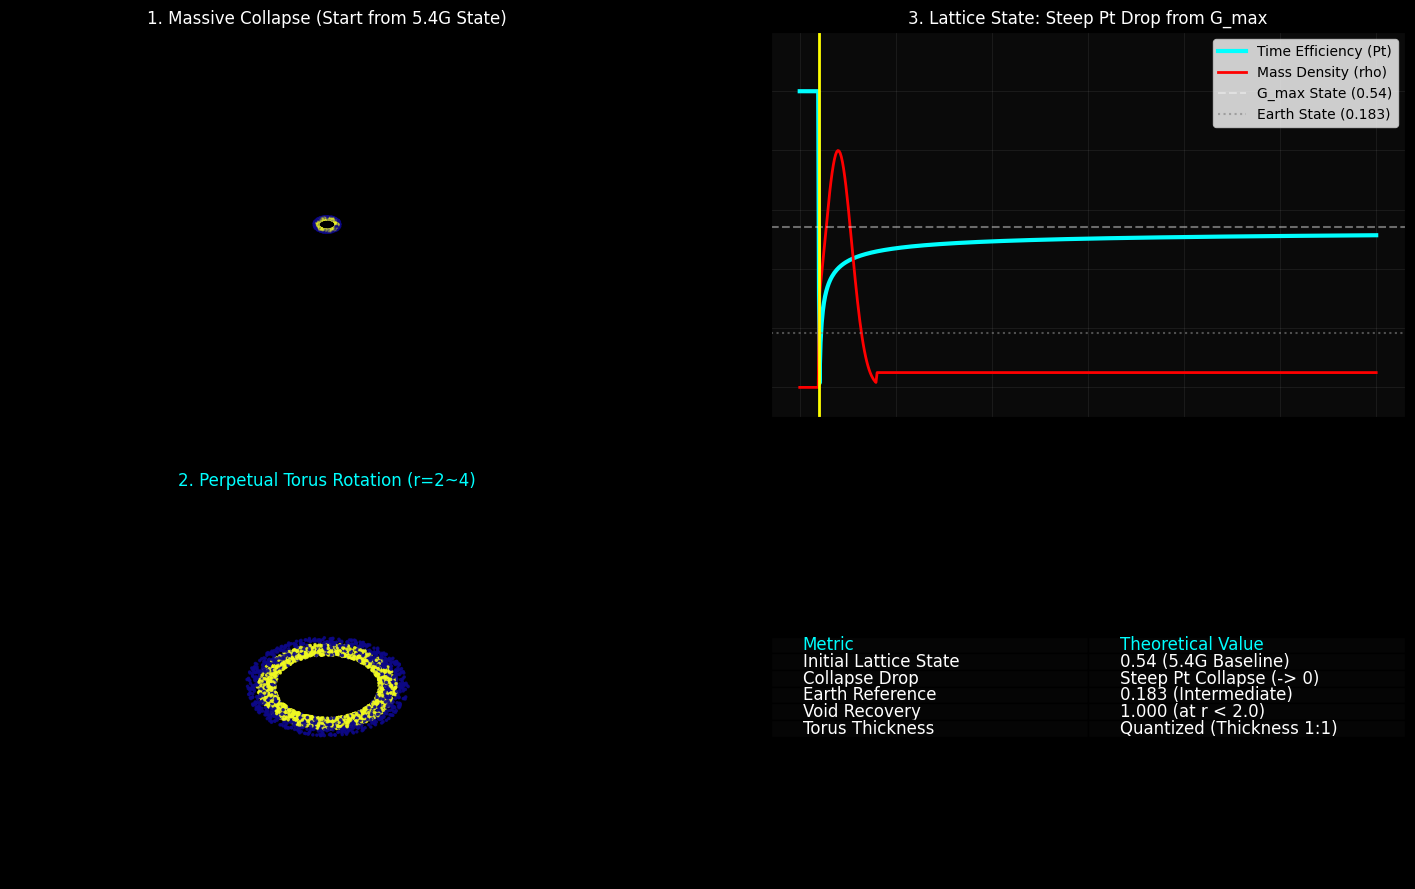

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from IPython import display
import time

# 1. Initial parameters and particle settings
n_particles = 3000 
cx, cy = 60, 60
r_initial = np.random.uniform(0, 55, n_particles)
theta_initial = np.random.uniform(0, 2*np.pi, n_particles)
px = cx + r_initial * np.cos(theta_initial)
py = cy + r_initial * np.sin(theta_initial)

def get_physics(x, y, frame):
    dx, dy = x - cx, y - cy
    r = np.sqrt(dx**2 + dy**2) + 0.1
    collapse = np.clip(frame / 120.0, 0, 1)
    
    # [Dynamics] Collapse and Powerful Vortex
    f_grav = -2.5 * collapse
    f_spin = 4.0 
    
    # Vortical Repulsion (r < 2.0)
    f_repulsion = np.where(r < 2.0, 7.0 * (2.0 - r) * (frame/60.0 if frame > 40 else 0), 0)
    
    ux = (dx * f_grav + dy * -f_spin + dx * f_repulsion) * 0.08
    uy = (dy * f_grav + dx * f_spin + dy * f_repulsion) * 0.08
    
    # [Modified Pt Formula] Starts at 0.54 (corresponding to 5.4G) and drops sharply
    # r < 2.0 (Vortical Void): Vertical restoration back to 1.0
    # r >= 2.0: As the collapse progresses, Pt drops from 0.54 to 0
    pt = np.where(r < 2.0, 1.0, np.clip(0.54 - (1.0 / (r - 1.95)**0.5), 0.0, 0.54))
    rho = np.where(r < 2.0, 0.0, np.where(r < 6.0, 1.0 * np.exp(-(r-4)**2/3), 0.05))
    return ux, uy, pt, rho

# 2. Running the integrated simulator
plt.ion()
fig = plt.figure(figsize=(18, 11), facecolor='black')

try:
    for frame in range(300):
        ux, uy, pt, rho_vals = get_physics(px, py, frame)
        px += ux
        py += uy
        
        plt.clf()
        # [top left: World View]
        ax1 = fig.add_subplot(2, 2, 1)
        ax1.set_facecolor('black')
        ax1.scatter(px, py, c=plt.cm.plasma(1-pt), s=1, alpha=0.4)
        ax1.set_xlim(0, 120); ax1.set_ylim(0, 120); ax1.axis('off')
        ax1.set_title("1. Massive Collapse (Start from 5.4G State)", color='white')

        # [Bottom left: Micro Vortex View] 
        ax2 = fig.add_subplot(2, 2, 3)
        ax2.set_facecolor('black')
        ax2.scatter(px, py, c=plt.cm.plasma(1-pt), s=2.5, alpha=0.8)
        ax2.set_xlim(cx-10, cx+10); ax2.set_ylim(cy-10, cy+10); ax2.axis('off')
        ax2.set_title("2. Perpetual Torus Rotation (r=2~4)", color='cyan')

        # [Top right: Sharp Pt drop graph]
        ax3 = fig.add_subplot(2, 2, 2)
        ax3.set_facecolor('#0a0a0a')
        r_range = np.linspace(0, 60, 500)
        # Pt curve that starts in the G_max state (0.54) and drops vertically near rv=2
        pt_curve = np.where(r_range < 2.0, 1.0, np.clip(0.54 - (0.2 / (r_range - 1.9)**0.5), 0.0, 0.54))
        rho_curve = np.where(r_range < 2.0, 0.0, np.where(r_range < 8.0, 0.8 * np.exp(-(r_range-4)**2/4), 0.05))
        
        ax3.plot(r_range, pt_curve, color='cyan', linewidth=3, label='Time Efficiency (Pt)')
        ax3.plot(r_range, rho_curve, color='red', linewidth=2, label='Mass Density (rho)')
        
        # Baseline display (0.54: 5.4G status / 0.183: Earth status)
        ax3.axhline(y=0.54, color='white', linestyle='--', alpha=0.4, label='G_max State (0.54)')
        ax3.axhline(y=0.183, color='gray', linestyle=':', alpha=0.6, label='Earth State (0.183)')
        
        current_r = np.mean(np.sqrt((px-cx)**2 + (py-cy)**2))
        ax3.axvline(x=current_r, color='yellow', linestyle='-', linewidth=2)
        
        ax3.set_ylim(-0.1, 1.2); ax3.legend(loc='upper right'); ax3.grid(alpha=0.1)
        ax3.set_title("3. Lattice State: Steep Pt Drop from G_max", color='white')

        # [Bottom right: Numerical table]
        ax4 = fig.add_subplot(2, 2, 4)
        ax4.axis('off')
        table_data = [
            ["Metric", "Theoretical Value"],
            ["Initial Lattice State", "0.54 (5.4G Baseline)"],
            ["Collapse Drop", "Steep Pt Collapse (-> 0)"],
            ["Earth Reference", "0.183 (Intermediate)"],
            ["Void Recovery", "1.000 (at r < 2.0)"],
            ["Torus Thickness", "Quantized (Thickness 1:1)"]
        ]
        table = ax4.table(cellText=table_data, loc='center', cellLoc='left', colWidths=[0.5, 0.5])
        table.auto_set_font_size(False); table.set_fontsize(12)
        for (row, col), cell in table.get_celld().items():
            cell.get_text().set_color('white'); cell.set_facecolor('#050505')
            if row == 0: cell.get_text().set_color('cyan')

        display.display(plt.gcf())
        display.clear_output(wait=True)
        time.sleep(0.01)

except KeyboardInterrupt:
    print("Simulation Terminated")
finally:
    plt.ioff()
